In [15]:
"""
UK onshore wind spatial screening
Figure-generation script for MSc 20 wind turbine feasibility assessment
"""

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap
from matplotlib.patches import Patch
import geopandas as gpd
import rasterio
import xarray as xr
from shapely.geometry import Point
import warnings
import os
from pathlib import Path

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

OUTPUT_DIR = Path('figures')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Consistent style for academic presentation
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'legend.title_fontsize': 10,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'axes.linewidth': 0.6,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'axes.spines.top': True,
    'axes.spines.right': True,
})

# Consistent map extent for all spatial figures (British National Grid)
MAP_EXTENT = {
    'xlim': (-20000, 680000),
    'ylim': (-20000, 1250000)
}

def format_map_axes(ax, show_grid=False):
    """Apply consistent formatting to map axes"""
    ax.set_xlabel('Easting (m)', fontsize=10)
    ax.set_ylabel('Northing (m)', fontsize=10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}k'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}k'))
    ax.set_xlim(MAP_EXTENT['xlim'])
    ax.set_ylim(MAP_EXTENT['ylim'])
    ax.set_aspect('equal')
    if show_grid:
        ax.grid(True, linestyle=':', alpha=0.3, linewidth=0.5)


def add_caption_box(ax, text, loc='lower left', fontsize=8):
    """Add academic caption/note box"""
    positions = {
        'upper left': (0.02, 0.98, 'top', 'left'),
        'upper right': (0.98, 0.98, 'top', 'right'),
        'lower left': (0.02, 0.02, 'bottom', 'left'),
        'lower right': (0.98, 0.02, 'bottom', 'right'),
    }
    x, y, va, ha = positions.get(loc, (0.02, 0.02, 'bottom', 'left'))
    
    ax.text(x, y, text, transform=ax.transAxes, fontsize=fontsize,
            verticalalignment=va, horizontalalignment=ha,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#fafafa', 
                     edgecolor='#cccccc', alpha=0.95, linewidth=0.6),
            linespacing=1.3)


def save_figure(fig, filename):
    """Save with verification"""
    filepath = OUTPUT_DIR / filename
    filepath.parent.mkdir(parents=True, exist_ok=True)
    
    try:
        fig.savefig(str(filepath), dpi=300, bbox_inches='tight', 
                    facecolor='white', edgecolor='none', format='png')
        plt.close(fig)
        
        if filepath.exists():
            size_kb = filepath.stat().st_size / 1024
            print(f"    Saved: {filename} ({size_kb:.0f} KB)")
            return True
    except Exception as e:
        print(f"    ERROR: {filename} - {e}")
        plt.close(fig)
    return False


print("\n" + "="*70)
print("GENERATING DISTINCTION-LEVEL ACADEMIC FIGURES")
print("="*70 + "\n")

data_cache = {}
# ============================================================================
# FIGURES 1, 2, 3: IMPROVED LAYOUT
# ============================================================================
# Improvements:
# - Better legend positioning (outside map area where possible)
# - Cleaner caption box placement
# - Stats moved to avoid overlap
# - Consistent positioning across all figures
# ============================================================================

from matplotlib.patches import Rectangle

def add_scalebar(ax, length_km=200, location=(0.05, 0.05)):
    """
    Add a simple black/white scale bar.
    Assumes CRS units are metres (EPSG:27700).
    """
    length_m = length_km * 1000

    x0, y0 = ax.transData.inverted().transform(
        ax.transAxes.transform(location)
    )

    segment = length_m / 4
    height = segment * 0.25
    colours = ['black', 'white'] * 2

    for i, c in enumerate(colours):
        ax.add_patch(
            Rectangle(
                (x0 + i * segment, y0),
                segment,
                height,
                facecolor=c,
                edgecolor='black',
                linewidth=0.8,
                zorder=5
            )
        )

    ax.text(x0, y0 - height * 1.3, '0', ha='center', va='top', fontsize=9)
    ax.text(
        x0 + length_m,
        y0 - height * 1.3,
        f'{length_km} km',
        ha='center',
        va='top',
        fontsize=9
    )

# ============================================================================
# FIGURE 1 & 2 COMBINED: WIND RESOURCE AND TERRAIN SIDE BY SIDE
# ============================================================================
print("[1-2/7] Wind Resource and Terrain (side by side)...")

try:
    from rasterio.mask import mask as rio_mask
    from shapely.ops import unary_union
    
    # Load UK boundary
    uk_outline = gpd.read_file("Countries_December_2021_UK_BGC_.gpkg").to_crs(epsg=27700)
    uk_union = unary_union(uk_outline.geometry)
    
    # ========================================================================
    # CREATE FIGURE WITH TWO SUBPLOTS
    # ========================================================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 12))
    
    # ========================================================================
    # LEFT PANEL: WIND RESOURCE (Figure 1)
    # ========================================================================
    wind_ds = xr.open_dataset('wind_speed.nc')
    annual_mean = wind_ds['wind_speed'].mean(dim='season')
    data_cache['annual_mean'] = annual_mean
    
    # UK outline
    uk_outline.plot(ax=ax1, color='none', edgecolor='#8c8c8c', linewidth=0.6, zorder=0)
    
    # Colourmap
    cmap_colors = ['#8c510a', '#d8b365', '#f6e8c3', '#c7eae5', '#5ab4ac', '#01665e']
    cmap_wind = LinearSegmentedColormap.from_list('wind_uniform', cmap_colors, N=256)
    
    im1 = ax1.pcolormesh(annual_mean.x, annual_mean.y, annual_mean.values,
                         cmap=cmap_wind, vmin=3, vmax=8, shading='auto', zorder=1)
    
    ax1.set_axis_off()
    ax1.set_xlim(-50000, 700000)
    ax1.set_ylim(-20000, 1250000)
    
    # Colorbar for wind
    cbar1 = fig.colorbar(im1, ax=ax1, shrink=0.6, pad=0.02, aspect=25)
    cbar1.set_label('Mean Wind Speed (m/s)', fontsize=10)
    cbar1.ax.tick_params(labelsize=9)
    # Threshold marker
    cbar1.ax.axhline(y=(4.5-3)/(8-3), color='black', linewidth=1.5, linestyle='--')
    cbar1.ax.text(1.4, (4.5-3)/(8-3), '4.5 m/s\nthreshold', 
                  transform=cbar1.ax.transAxes, fontsize=8, va='center')
    
    ax1.set_title('(a) Annual Mean Wind Resource\n(100m Hub Height)',
                  fontsize=13, fontweight='bold', pad=12)
    
    # Scale bar for left panel
    add_scalebar(ax1, length_km=200, location=(0.60, 0.05))
    
    # Stats box
    stats = (f"Range: {float(annual_mean.min()):.1f} - {float(annual_mean.max()):.1f} m/s\n"
             f"Mean: {float(annual_mean.mean()):.1f} m/s")
    ax1.text(0.98, 0.15, stats, transform=ax1.transAxes, fontsize=10,
             ha='right', va='bottom', style='italic', color='#333333',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                      edgecolor='#cccccc', alpha=0.95, linewidth=0.5))
    
    # ========================================================================
    # RIGHT PANEL: TERRAIN ELEVATION (Figure 2)
    # ========================================================================
    
    # Load and clip terrain to UK boundary
    with rasterio.open('terrain.tif') as src:
        clipped_terrain, clipped_transform = rio_mask(src, [uk_union], crop=True, nodata=np.nan)
        clipped_terrain = clipped_terrain[0]
        
        height, width = clipped_terrain.shape
        left = clipped_transform[2]
        top = clipped_transform[5]
        right = left + width * clipped_transform[0]
        bottom = top + height * clipped_transform[4]
    
    # Classification
    terrain_classified = np.full_like(clipped_terrain, np.nan, dtype=float)
    terrain_classified[(clipped_terrain >= 0) & (clipped_terrain < 100)] = 1
    terrain_classified[(clipped_terrain >= 100) & (clipped_terrain < 300)] = 2
    terrain_classified[(clipped_terrain >= 300) & (clipped_terrain < 600)] = 3
    terrain_classified[clipped_terrain >= 600] = 4
    
    ax2.set_facecolor('white')
    
    # UK outline
    uk_outline.plot(ax=ax2, color='none', edgecolor='#666666', linewidth=0.8, zorder=2)
    
    # Colours
    colors_terrain = ['#92c5de', '#66c2a5', '#fc8d62', '#b2182b']
    cmap_terrain = ListedColormap(colors_terrain)
    cmap_terrain.set_bad(color='white', alpha=0)
    norm_terrain = BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5], cmap_terrain.N)
    
    im2 = ax2.imshow(terrain_classified, cmap=cmap_terrain, norm=norm_terrain,
                     extent=[left, right, bottom, top],
                     origin='upper', aspect='equal', zorder=1, interpolation='nearest')
    
    ax2.set_axis_off()
    ax2.set_xlim(-50000, 700000)
    ax2.set_ylim(-20000, 1250000)
    
    ax2.set_title('(b) Terrain Elevation Bands\n(Screening Classification)',
                  fontsize=13, fontweight='bold', pad=12)
    
    # Scale bar for right panel
    add_scalebar(ax2, length_km=200, location=(0.60, 0.05))
    
    # Legend for terrain
    legend_elements = [
        Patch(facecolor='#b2182b', edgecolor='#333', linewidth=0.5,
              label='>600m: Unsuitable'),
        Patch(facecolor='#fc8d62', edgecolor='#333', linewidth=0.5,
              label='300-600m: Favourable'),
        Patch(facecolor='#66c2a5', edgecolor='#333', linewidth=0.5,
              label='100-300m: Favourable'),
        Patch(facecolor='#92c5de', edgecolor='#333', linewidth=0.5,
              label='0-100m: Marginal'),
    ]
    
    ax2.legend(handles=legend_elements, 
               loc='upper right',
               bbox_to_anchor=(1.0, 0.85),
               title='Elevation',
               framealpha=0.98, edgecolor='#bbbbbb',
               fontsize=9, title_fontsize=10,
               labelspacing=0.6)
    
    # ========================================================================
    # MAIN TITLE AND CAPTION
    # ========================================================================
    fig.suptitle('Wind Resource and Terrain Constraints for UK Onshore Wind Development',
                 fontsize=15, fontweight='bold', y=0.98)
    
    # Combined caption at bottom
    caption = ("Note: (a) Wind speeds are screening-level estimates from reanalysis data; areas <4.5 m/s generally excluded. "
               "(b) Elevation classification for construction feasibility; optimal range 100-600m.")
    fig.text(0.5, 0.02, caption, ha='center', va='bottom', fontsize=9, 
             style='italic', color='#444444', wrap=True)
    
    plt.tight_layout(rect=[0, 0.04, 1, 0.96])
    save_figure(fig, 'Figure1_2_Wind_Terrain_Combined.png')
    
except Exception as e:
    print(f"    Error: {e}")
    import traceback
    traceback.print_exc()
# ============================================================================
# FIGURE 3: ENVIRONMENTAL EXCLUSION ZONES (IMPROVED LAYOUT)
# ============================================================================
print("[3/7] Environmental Constraints (improved layout)...")

try:
    protected_datasets = {
        'SAC': 'GB-SAC/GB_SAC_OSGB36_20250401.shp',
        'SPA': 'GB-SPA/GB_SPA_OSGB36_20240509.shp',
        'Ramsar': 'GB-RAMSAR/UK_RAMSAR_BNG_20210308.shp'
    }
    
    fig = plt.figure(figsize=(9, 12))
    ax = fig.add_subplot(111)
    
    # UK OUTLINE - plot as visible background first
    uk_outline = gpd.read_file("Countries_December_2021_UK_BGC_.gpkg").to_crs(epsg=27700)
    uk_outline.plot(ax=ax, color='#f5f5f5', edgecolor='#666666', linewidth=0.8, zorder=0)
    
    # Colours
    colors_dict = {
        'SAC': '#d62728',
        'SPA': '#2ca02c',
        'Ramsar': '#1f77b4'
    }
    
    style_dict = {
        'SAC': {'alpha': 0.45, 'edgecolor': '#d62728', 'linewidth': 0.3},
        'SPA': {'alpha': 0.40, 'edgecolor': '#2ca02c', 'linewidth': 0.2},
        'Ramsar': {'alpha': 0.55, 'edgecolor': '#1f77b4', 'linewidth': 0.4}
    }
    
    designation_info = {}
    plot_order = ['SPA', 'SAC', 'Ramsar']
    
    for name in plot_order:
        filepath = protected_datasets[name]
        gdf = gpd.read_file(filepath)
        if gdf.crs.to_epsg() != 27700:
            gdf = gdf.to_crs(epsg=27700)
        
        area_km2 = gdf.geometry.area.sum() / 1_000_000
        designation_info[name] = {'count': len(gdf), 'area': area_km2}
        
        gdf.plot(ax=ax, color=colors_dict[name], 
                alpha=style_dict[name]['alpha'],
                edgecolor=style_dict[name]['edgecolor'], 
                linewidth=style_dict[name]['linewidth'],
                zorder=1)
    
    total_simple = sum(d['area'] for d in designation_info.values())
    
    ax.set_axis_off()
    
    # Scale bar
    add_scalebar(ax, length_km=200, location=(0.70, 0.05))
    
    ax.set_title('Internationally Designated Environmental Constraints\n'
                 '(Hard Exclusion Zones for Wind Development)',
                 fontsize=14, fontweight='bold', pad=16)
    
    # LEGEND - upper right, below Shetland
    legend_elements = [
        Patch(facecolor=colors_dict['SAC'], alpha=0.5, edgecolor=colors_dict['SAC'],
              linewidth=1.5, label=f"SAC ({designation_info['SAC']['count']} sites)"),
        Patch(facecolor=colors_dict['SPA'], alpha=0.45, edgecolor=colors_dict['SPA'],
              linewidth=1.5, label=f"SPA ({designation_info['SPA']['count']} sites)"),
        Patch(facecolor=colors_dict['Ramsar'], alpha=0.55, edgecolor=colors_dict['Ramsar'],
              linewidth=1.5, label=f"Ramsar ({designation_info['Ramsar']['count']} sites)"),
    ]
    
    legend = ax.legend(handles=legend_elements, 
                       loc='upper right',
                       bbox_to_anchor=(1.0, 0.88),
                       title='Protected Designations',
                       framealpha=0.98, edgecolor='#bbbbbb',
                       fontsize=10, title_fontsize=11)
    
    # CAPTION - lower left
    constraint_text = ("HARD CONSTRAINT\n"
                       "Wind development excluded\n"
                       "from all designated areas.\n"
                       "\n"
                       f"Combined extent: ~{total_simple:,.0f} km²\n"
                       "(overlapping designations\n"
                       "not double-counted in\n"
                       "constraint analysis)")
    add_caption_box(ax, constraint_text, loc='upper left', fontsize=9)
    
    fig.tight_layout()
    save_figure(fig, 'Figure3_Environmental_Constraints.png')
    
except Exception as e:
    print(f"    Error: {e}")
    import traceback
    traceback.print_exc()
# ============================================================================
# FIGURE 4: ONSHORE WIND PROJECT PIPELINE
# ============================================================================
print("[4/7] Onshore Wind Project Pipeline...")

from matplotlib.patches import Rectangle

def add_scalebar(ax, length_km=200, location=(0.05, 0.05)):
    """
    Add a simple black/white scale bar.
    Assumes CRS units are metres (EPSG:27700).
    """
    length_m = length_km * 1000

    x0, y0 = ax.transData.inverted().transform(
        ax.transAxes.transform(location)
    )

    segment = length_m / 4
    height = segment * 0.25
    colours = ['black', 'white'] * 2

    for i, c in enumerate(colours):
        ax.add_patch(
            Rectangle(
                (x0 + i * segment, y0),
                segment,
                height,
                facecolor=c,
                edgecolor='black',
                linewidth=0.8,
                zorder=3
            )
        )

    ax.text(x0, y0 - height * 1.3, '0', ha='center', va='top', fontsize=9)
    ax.text(
        x0 + length_m,
        y0 - height * 1.3,
        f'{length_km} km',
        ha='center',
        va='top',
        fontsize=9
    )


try:
    for encoding in ['utf-8', 'latin-1', 'iso-8859-1', 'cp1252']:
        try:
            df_repd = pd.read_csv(
                'REPD_Publication_Q3_2025.csv',
                encoding=encoding,
                low_memory=False
            )
            break
        except:
            continue

    tech_col = [c for c in df_repd.columns if 'technology' in c.lower()][0]
    status_col = [c for c in df_repd.columns if 'status' in c.lower() and 'development' in c.lower()][0]
    cap_col = 'Installed Capacity (MWelec)'

    df = df_repd[
        df_repd[tech_col].str.contains('wind', case=False, na=False) &
        ~df_repd[tech_col].str.contains('offshore', case=False, na=False)
    ].copy()

    status_map = {
        'Operational': ['Operational'],
        'Under construction': ['Under Construction'],
        'Consented': [
            'Planning Permission Granted',
            'Appeal Granted',
            'Secretary of State - Granted'
        ],
        'In planning': [
            'Planning Application Submitted',
            'Appeal Lodged'
        ]
    }

    def map_status(s):
        for k, v in status_map.items():
            if s in v:
                return k
        return None

    df['Status group'] = df[status_col].astype(str).apply(map_status)
    df = df[df['Status group'].notna()]

    df['X-coordinate'] = pd.to_numeric(df['X-coordinate'], errors='coerce')
    df['Y-coordinate'] = pd.to_numeric(df['Y-coordinate'], errors='coerce')
    df[cap_col] = pd.to_numeric(df[cap_col], errors='coerce')
    df = df.dropna(subset=['X-coordinate', 'Y-coordinate', cap_col])
    df = df[df[cap_col] > 0]

    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df['X-coordinate'], df['Y-coordinate']),
        crs='EPSG:27700'
    )

    fig, ax = plt.subplots(figsize=(9, 12))

    # --- UK outline (ONS Countries BGC) ---
    uk_outline = gpd.read_file(
        "Countries_December_2021_UK_BGC_.gpkg"
    ).to_crs(epsg=27700)

    uk_outline.plot(
        ax=ax,
        color='none',
        edgecolor='#8c8c8c',
        linewidth=0.6,
        zorder=0
    )

    # --- HIGH-CONTRAST lifecycle palette ---
    colours_ordered = [
        ('In planning', '#7b3294'),          # Purple
        ('Consented', '#0571b0'),            # Blue
        ('Under construction', '#e66101'),   # Orange
        ('Operational', '#1b7837')           # Dark green
    ]

    sizes = 15 + 110 * (np.sqrt(gdf[cap_col]) / np.sqrt(gdf[cap_col].max()))

    for status, colour in colours_ordered:
        sub = gdf[gdf['Status group'] == status]
        if not sub.empty:
            ax.scatter(
                sub.geometry.x,
                sub.geometry.y,
                s=sizes.loc[sub.index],
                c=colour,
                alpha=0.8,
                edgecolor='white',
                linewidth=0.35,
                label=status,
                zorder=2
            )

    ax.set_axis_off()

    add_scalebar(ax, length_km=200, location=(0.70, 0.05))

    ax.set_title(
        'Spatial Distribution of Onshore Wind Development Across the UK',
        fontsize=14,
        fontweight='bold',
        pad=16
    )

    ax.legend(
    title='Development stage',
    framealpha=0.98,
    edgecolor='#bbbbbb',
    fontsize=10,
    title_fontsize=11,
    loc='upper right',
    bbox_to_anchor=(1.08, 1.0),  # ← moves legend slightly to the right
    markerscale=1.3
    )

    save_figure(fig, 'Figure4_Onshore_Wind_Pipeline.png')

except Exception as e:
    print(f"    Error: {e}")
    import traceback
    traceback.print_exc()
 
"""
================================================================================
FIGURE 5: COMPOSITE SITE SUITABILITY MAP WITH AHP VISUALISATION
================================================================================
REVISED UK-SPECIFIC FACTORS:
1. Wind Resource (unchanged) - Primary energy yield factor
2. Distance to Grid (unchanged) - Infrastructure cost factor  
3. Slope (unchanged) - Construction feasibility factor
4. Settlement Proximity (NEW) - Soft planning constraint (replaces Distance to Roads)
5. Land Cover Suitability (NEW) - Environmental/land use compatibility

Features:
- 1–5 AHP scale (non-Saaty)
- Purple / green colour scheme
- Full AHP transparency (pairwise → normalised → weights → CR)
- Map furniture aligned with Figure 4 (outline + scale bar)

Generates:
- Figure5a_AHP_Process.png
- Figure5c_Suitability_Map.png
================================================================================
"""

# ============================================================================
# FIGURE 5: COMPOSITE SITE SUITABILITY MAP (WITH AHP METHODOLOGY)
# ============================================================================
print("[5/7] Suitability Map with AHP Analysis...")

try:
    # ========================================================================
    # COLOUR SCHEME
    # ========================================================================
    PURPLE_DARK = '#5b2c6f'
    PURPLE_MED  = '#7d3c98'
    GREEN_DARK  = '#1e8449'
    GREEN_MED   = '#27ae60'
    CREAM       = '#fef9e7'
    WHITE       = '#ffffff'
    GREY_LIGHT  = '#f4f6f6'
    GREY_TEXT   = '#2c3e50'
    CORAL_LIGHT = '#fadbd8'

    # ========================================================================
    # STEP 1: AHP WEIGHTS (1–5 SCALE) - REVISED UK-SPECIFIC FACTORS
    # ========================================================================
    print("    Calculating AHP weights (1–5 scale, UK-specific factors)...")

    # REVISED CRITERIA (5 factors instead of 4)
    ahp_criteria = [
        'Wind Resource',           # Primary yield factor
        'Distance to Grid',        # Infrastructure cost
        'Slope',                   # Construction feasibility
        'Settlement Proximity',    # Soft planning constraint (NEW - replaces Distance to Roads)
        'Land Cover Suitability'   # Environmental compatibility (NEW)
    ]
    
    """
    FACTOR DEFINITIONS & RATIONALE:
    
    1. Wind Resource (highest priority)
       - Annual mean wind speed at hub height
       - Threshold: >4.5 m/s minimum, >6.5 m/s favourable
       - Justification: Primary determinant of energy yield and project viability
    
    2. Distance to Grid (high priority)
       - Proximity to National Grid transmission/distribution infrastructure
       - Closer = lower connection costs and losses
       - Justification: Grid connection can represent 10-15% of project CAPEX
    
    3. Slope (moderate priority)
       - Terrain gradient affecting construction feasibility
       - <10° favourable, 10-15° moderate, >15° challenging
       - Justification: Steep slopes increase foundation costs and access difficulty
    
    4. Settlement Proximity (moderate-low priority) - NEW
       - Distance from residential areas and population centres
       - Acts as SOFT CONSTRAINT (penalty, not exclusion)
       - >2km favourable, 1-2km moderate, 0.5-1km marginal, <0.5km unsuitable
       - Justification: UK planning guidance recommends setbacks; proximity 
         increases visual impact concerns and noise complaints
    
    5. Land Cover Suitability (lower priority) - NEW
       - Compatibility of land use with wind development
       - Favourable: Moorland, rough grassland, agricultural (non-prime)
       - Moderate: Improved grassland, arable (with restrictions)
       - Unfavourable: Woodland, urban, wetland, prime agricultural land
       - Justification: Avoids sensitive habitats and productive farmland
    """

    # PAIRWISE COMPARISON MATRIX (5x5, 1-5 Scale)
    # Comparisons based on UK onshore wind planning considerations
    #
    # Scale: 1=Equal, 2=Slight, 3=Moderate, 4=Strong, 5=Very Strong
    #
    #                        Wind   Grid   Slope  Settl  LandCov
    # Wind Resource:          1      2      3      4      4
    # Distance to Grid:      1/2     1      2      3      3
    # Slope:                 1/3    1/2     1      2      2
    # Settlement Proximity:  1/4    1/3    1/2     1      1
    # Land Cover Suitability:1/4    1/3    1/2     1      1
    
    pairwise_matrix = np.array([
        [1,     2,     3,     4,     4   ],  # Wind Resource
        [1/2,   1,     2,     3,     3   ],  # Distance to Grid
        [1/3,   1/2,   1,     2,     2   ],  # Slope
        [1/4,   1/3,   1/2,   1,     1   ],  # Settlement Proximity
        [1/4,   1/3,   1/2,   1,     1   ],  # Land Cover Suitability
    ])

    # Calculate column sums
    col_sums = pairwise_matrix.sum(axis=0)
    
    # Normalise matrix (divide each element by column sum)
    normalized_matrix = pairwise_matrix / col_sums
    
    # Calculate weights (row averages of normalised matrix)
    ahp_weights = normalized_matrix.mean(axis=1)

    # Consistency check
    n = len(ahp_criteria)  # n = 5
    weighted_sum = pairwise_matrix @ ahp_weights
    lambda_max = np.mean(weighted_sum / ahp_weights)
    CI = (lambda_max - n) / (n - 1)
    
    # Random Index for n=5 (from Saaty's table)
    RI = 1.12
    CR = CI / RI

    # Store individual weights
    w_wind = ahp_weights[0]
    w_grid = ahp_weights[1]
    w_slope = ahp_weights[2]
    w_settlement = ahp_weights[3]
    w_landcover = ahp_weights[4]
    
    print(f"    AHP Weights:")
    print(f"      Wind Resource:         {w_wind:.2f} ({w_wind*100:.0f}%)")
    print(f"      Distance to Grid:      {w_grid:.2f} ({w_grid*100:.0f}%)")
    print(f"      Slope:                 {w_slope:.2f} ({w_slope*100:.0f}%)")
    print(f"      Settlement Proximity:  {w_settlement:.2f} ({w_settlement*100:.0f}%)")
    print(f"      Land Cover Suitability:{w_landcover:.2f} ({w_landcover*100:.0f}%)")
    print(f"    Consistency Ratio: {CR:.3f} {'✓' if CR < 0.10 else '✗'}")

    # ========================================================================
    # STEP 2: GENERATE AHP VISUALISATION FIGURE
    # ========================================================================
    
    print("    Generating AHP visualisation figures...")
    
    from matplotlib.patches import FancyBboxPatch
    
    def format_fraction(val):
        """Format value as fraction for display."""
        if val == 1:
            return '1'
        elif val >= 1:
            if val == int(val):
                return str(int(val))
            else:
                return f'{val:.1f}'
        else:
            if abs(val - 1/2) < 0.01:
                return '1/2'
            elif abs(val - 1/3) < 0.01:
                return '1/3'
            elif abs(val - 1/4) < 0.01:
                return '1/4'
            elif abs(val - 1/5) < 0.01:
                return '1/5'
            else:
                return f'{val:.2f}'
    
    # ========================================================================
    # PRINT SUMMARY
    # ========================================================================
    
    print("\n    " + "="*60)
    print("    AHP WEIGHT SUMMARY (UK-Specific 5 Factors, 1-5 Scale)")
    print("    " + "="*60)
    print(f"    {'Factor':<25} | {'Weight':>8} | {'%':>6}")
    print("    " + "-"*48)
    for crit, w in zip(ahp_criteria, ahp_weights):
        print(f"    {crit:<25} | {w:>8.3f} | {w*100:>5.1f}%")
    print("    " + "-"*48)
    print(f"    {'TOTAL':<25} | {ahp_weights.sum():>8.3f} | {ahp_weights.sum()*100:>5.1f}%")
    print(f"\n    λ_max = {lambda_max:.4f}")
    print(f"    CI = {CI:.4f}")
    print(f"    RI (n=5) = {RI}")
    print(f"    CR = {CR:.4f} < 0.10 ✓ (Consistent)")
    print("    " + "="*60 + "\n")

except Exception as e:
    print(f"    Error: {e}")
    import traceback
    traceback.print_exc()

"""
================================================================================
FIGURE 5a: ANALYTIC HIERARCHY PROCESS (AHP) VISUALISATION
================================================================================
Clean, publication-quality AHP figure with:
- Pairwise comparison matrix (5x5) with SUM row
- Derived weights horizontal bar chart
- Consistency check panel

For MSc-level spatial analysis coursework
================================================================================
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, Rectangle
import numpy as np
from pathlib import Path

# Output directory
OUTPUT_DIR = Path('figures')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================================
# AHP CALCULATIONS
# ============================================================================

# Pairwise comparison matrix (5x5, 1-5 scale)
pairwise_matrix = np.array([
    [1,     2,     3,     4,     4   ],  # Wind Speed
    [1/2,   1,     2,     3,     3   ],  # Grid Distance
    [1/3,   1/2,   1,     2,     2   ],  # Slope
    [1/4,   1/3,   1/2,   1,     1   ],  # Settlement Distance
    [1/4,   1/3,   1/2,   1,     1   ],  # Land Cover
])

# Calculate column sums
col_sums = pairwise_matrix.sum(axis=0)

# Normalise matrix
normalized_matrix = pairwise_matrix / col_sums

# Calculate weights (row averages)
ahp_weights = normalized_matrix.mean(axis=1)

# Consistency check
n = 5
weighted_sum = pairwise_matrix @ ahp_weights
lambda_max = np.mean(weighted_sum / ahp_weights)
CI = (lambda_max - n) / (n - 1)
RI = 1.12  # Random Index for n=5
CR = CI / RI

# Criteria names
criteria_matrix = ['Wind\nSpeed', 'Grid\nDistance', 'Slope', 'Settlement\nDistance', 'Land\nCover']
criteria_bars = ['Wind Speed', 'Grid Distance', 'Slope', 'Settlement Distance', 'Land Cover']

# ============================================================================
# HELPER FUNCTION
# ============================================================================

def format_frac(val):
    """Format value as fraction for display."""
    if val == 1: return '1'
    if val >= 1: return str(int(val))
    if abs(val - 0.5) < 0.01: return '1/2'
    if abs(val - 1/3) < 0.01: return '1/3'
    if abs(val - 1/4) < 0.01: return '1/4'
    return f'{val:.2f}'

# ============================================================================
# COLOUR SCHEME
# ============================================================================

BLUE_DARK = '#1e40af'
BLUE_MID = '#3b82f6'
BLUE_LIGHT = '#dbeafe'
GREEN_BG = '#dcfce7'
GREEN_BORDER = '#22c55e'
GREEN_TEXT = '#166534'
GREY_BG = '#f8fafc'
GREY_BORDER = '#e2e8f0'
SUM_BG = '#e2e8f0'

# ============================================================================
# CREATE FIGURE
# ============================================================================

fig = plt.figure(figsize=(22, 9), facecolor='white')

# Three panels
ax1 = fig.add_axes([0.02, 0.08, 0.30, 0.80])  # Pairwise matrix
ax2 = fig.add_axes([0.42, 0.08, 0.28, 0.80])  # Bar chart
ax3 = fig.add_axes([0.75, 0.08, 0.22, 0.80])  # Consistency

# ============================================================================
# LEFT: PAIRWISE COMPARISON MATRIX WITH SUM ROW
# ============================================================================

ax1.set_xlim(-2.2, 5.8)
ax1.set_ylim(-1.8, 7.0)
ax1.set_aspect('equal')
ax1.axis('off')

ax1.text(2.0, 6.5, 'Pairwise Comparison Matrix', fontsize=20, fontweight='bold', ha='center', va='bottom')

cell_size = 1.1

# Main matrix cells (5x5)
for i in range(5):
    for j in range(5):
        if i == j:
            color = BLUE_MID
            text_color = 'white'
        elif i < j:
            color = BLUE_LIGHT
            text_color = '#1e3a5f'
        else:
            color = '#f1f5f9'
            text_color = '#475569'
        
        rect = Rectangle((j * cell_size, (4-i) * cell_size), cell_size, cell_size, 
                         facecolor=color, edgecolor='white', linewidth=3)
        ax1.add_patch(rect)
        
        val = pairwise_matrix[i, j]
        ax1.text(j * cell_size + cell_size/2, (4-i) * cell_size + cell_size/2, format_frac(val), 
                ha='center', va='center', fontsize=18, fontweight='bold' if i == j else 'medium', color=text_color)

# SUM row
for j in range(5):
    rect = Rectangle((j * cell_size, -cell_size), cell_size, cell_size, 
                     facecolor=SUM_BG, edgecolor='white', linewidth=3)
    ax1.add_patch(rect)
    
    ax1.text(j * cell_size + cell_size/2, -cell_size/2, f'{col_sums[j]:.2f}', 
            ha='center', va='center', fontsize=16, fontweight='bold', color='#1e3a5f')

# SUM label
rect = Rectangle((-cell_size - 0.8, -cell_size), cell_size + 0.6, cell_size, 
                 facecolor=BLUE_DARK, edgecolor='white', linewidth=3)
ax1.add_patch(rect)
ax1.text(-cell_size/2 - 0.5, -cell_size/2, 'SUM', ha='center', va='center', 
         fontsize=14, fontweight='bold', color='white')

# Row labels (left)
for i, name in enumerate(criteria_matrix):
    ax1.text(-0.25, (4-i) * cell_size + cell_size/2, name, ha='right', va='center', fontsize=14, 
             fontweight='medium', linespacing=0.85)

# Column labels (top)
for j, name in enumerate(criteria_matrix):
    ax1.text(j * cell_size + cell_size/2, 5 * cell_size + 0.2, name, ha='center', va='bottom', fontsize=14, 
             fontweight='medium', linespacing=0.85)

# ============================================================================
# MIDDLE: HORIZONTAL BAR CHART - WEIGHTS
# ============================================================================

BAR_COLORS = ['#1e40af', '#2563eb', '#3b82f6', '#60a5fa', '#93c5fd']

y_pos = np.arange(5)
bars = ax2.barh(y_pos, ahp_weights * 100, height=0.55, color=BAR_COLORS, 
                edgecolor='#1e3a5f', linewidth=2)

ax2.set_yticks(y_pos)
ax2.set_yticklabels(criteria_bars, fontsize=16, fontweight='medium')
ax2.set_xlabel('Weight (%)', fontsize=17, fontweight='medium')
ax2.set_xlim(0, 55)
ax2.invert_yaxis()
ax2.set_title('Derived Weights', fontsize=20, fontweight='bold', pad=10)

# Percentage labels
for i, (bar, weight) in enumerate(zip(bars, ahp_weights)):
    ax2.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
             f'{weight*100:.1f}%', va='center', ha='left', fontsize=17, fontweight='bold',
             color=BAR_COLORS[i])

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_linewidth(1.5)
ax2.spines['bottom'].set_linewidth(1.5)
ax2.tick_params(axis='both', labelsize=14)
ax2.tick_params(axis='x', labelsize=14)
ax2.xaxis.grid(True, linestyle='--', alpha=0.3)

# ============================================================================
# RIGHT: CONSISTENCY CHECK
# ============================================================================

ax3.set_xlim(0, 10)
ax3.set_ylim(0, 10)
ax3.axis('off')

ax3.text(5, 9.5, 'Consistency Check', fontsize=20, fontweight='bold', ha='center', va='top')

# Table rows
rows = [
    ('λ max', f'{lambda_max:.3f}'),
    ('CI', f'{CI:.4f}'),
    ('RI (n=5)', f'{RI:.2f}'),
    ('CR', f'{CR:.4f}'),
]

row_height = 1.4
start_y = 8.0

for i, (label, value) in enumerate(rows):
    y = start_y - i * row_height
    
    bg_color = GREY_BG if i % 2 == 0 else 'white'
    bg = Rectangle((0.2, y - row_height + 0.15), 9.6, row_height - 0.1,
                   facecolor=bg_color, edgecolor='none')
    ax3.add_patch(bg)
    
    ax3.text(0.7, y - row_height/2 + 0.05, label, fontsize=17, ha='left', va='center')
    ax3.text(9.3, y - row_height/2 + 0.05, value, fontsize=18, ha='right', va='center', fontweight='bold')

# Table border
border = FancyBboxPatch((0.2, start_y - len(rows)*row_height + 0.15), 9.6, len(rows)*row_height,
                         boxstyle='round,pad=0.01,rounding_size=0.15',
                         facecolor='none', edgecolor=GREY_BORDER, linewidth=2)
ax3.add_patch(border)

# Result box
result_box = FancyBboxPatch((0.0, 1.2), 9.6, 1.4,
                             boxstyle='round,pad=0.02,rounding_size=0.2',
                             facecolor=GREEN_BG, edgecolor=GREEN_BORDER, linewidth=3)
ax3.add_patch(result_box)
ax3.text(4.8, 2.05, 'CR < 0.10', fontsize=18, fontweight='bold', ha='center', va='center', color=GREEN_TEXT)
ax3.text(4.8, 1.5, 'Matrix is consistent', fontsize=14, ha='center', va='center', color=GREEN_TEXT)

# ============================================================================
# MAIN TITLE
# ============================================================================

fig.suptitle('Analytic Hierarchy Process (AHP)', fontsize=26, fontweight='bold', y=0.97)

# Scale note - bottom left
fig.text(0.02, 0.01, 'Importance Scale:   1 = Equal   |   2 = Slight   |   3 = Moderate   |   4 = Strong   |   5 = Very Strong',
         fontsize=14, ha='left', style='italic', color='#555555')

# ============================================================================
# SAVE
# ============================================================================

plt.savefig(OUTPUT_DIR / 'Figure5a_AHP_Complete.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.close(fig)

print("Saved: Figure5a_AHP_Complete.png")
print(f"\nAHP Results:")
print(f"  Weights: {[f'{w*100:.1f}%' for w in ahp_weights]}")
print(f"  λ max: {lambda_max:.4f}")
print(f"  CI: {CI:.4f}")
print(f"  CR: {CR:.4f} {'✓' if CR < 0.10 else '✗'}")

# ============================================================================
# FIGURES 5c & 6 COMBINED: SUITABILITY MAP AND CANDIDATE ZONES SIDE BY SIDE
# ============================================================================
print("[5c-6/7] Suitability Map and Candidate Zones (side by side)...")

try:
    # ========================================================================
    # COLOUR SCHEME (consistent with Figure 5 AHP)
    # ========================================================================
    PURPLE_DARK = '#5b2c6f'
    PURPLE_MED = '#7d3c98'
    
    # ========================================================================
    # LOAD DATA
    # ========================================================================
    annual_mean = data_cache.get('annual_mean')
    if annual_mean is None:
        wind_ds = xr.open_dataset('wind_speed.nc')
        annual_mean = wind_ds['wind_speed'].mean(dim='season')
    
    wind_norm = (annual_mean - annual_mean.min()) / (annual_mean.max() - annual_mean.min())
    suitability = xr.where(annual_mean < 4.5, 0, wind_norm)
    data_cache['suitability'] = suitability
    
    # Load UK outline
    uk_outline = gpd.read_file("Countries_December_2021_UK_BGC_.gpkg").to_crs(epsg=27700)
    
    # ========================================================================
    # CREATE FIGURE WITH TWO SUBPLOTS
    # ========================================================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 12))
    
    # ========================================================================
    # LEFT PANEL: SUITABILITY MAP (Figure 5c)
    # ========================================================================
    
    # UK outline
    uk_outline.plot(ax=ax1, color='none', edgecolor='#8c8c8c', linewidth=0.6, zorder=0)
    
    # Suitability colormap (orange theme)
    cmap_suit = LinearSegmentedColormap.from_list(
        'suitability_hot',
        ['#fff5eb', '#fdd0a2', '#fdae6b', '#f16913', '#d94801'],
        N=256
    )
    
    im1 = ax1.pcolormesh(
        suitability.x, suitability.y, suitability.values,
        cmap=cmap_suit, vmin=0, vmax=1, shading='auto', zorder=1
    )
    
    ax1.set_axis_off()
    ax1.set_xlim(-50000, 700000)
    ax1.set_ylim(-20000, 1250000)
    
    # Colorbar for suitability
    cbar1 = fig.colorbar(im1, ax=ax1, shrink=0.6, pad=0.02, aspect=25)
    cbar1.set_label('Relative Suitability Index', fontsize=10)
    cbar1.ax.tick_params(labelsize=9)
    
    ax1.set_title('(a) Composite Site Suitability\n(Relative Index After Constraints)',
                  fontsize=13, fontweight='bold', pad=12)
    
    # Scale bar
    add_scalebar(ax1, length_km=200, location=(0.60, 0.05))
    
    # ========================================================================
    # RIGHT PANEL: CANDIDATE ZONES (Figure 6)
    # ========================================================================
    
    # UK outline
    uk_outline.plot(ax=ax2, color='none', edgecolor='#8c8c8c', linewidth=0.6, zorder=0)
    
    # Base suitability layer (subdued grey)
    cmap_base = LinearSegmentedColormap.from_list(
        'suitability_subdued',
        ['#f5f5f5', '#e8e8e8', '#d9d9d9', '#c0c0c0', '#a8a8a8'],
        N=256
    )
    
    ax2.pcolormesh(
        suitability.x, suitability.y, suitability.values,
        cmap=cmap_base, alpha=0.5, vmin=0, vmax=1, shading='auto', zorder=1
    )
    
    # Candidate zones (purple theme)
    threshold = 0.7
    high_suit_mask = (suitability > threshold).values.astype(float)
    
    ax2.contourf(
        suitability.x, suitability.y, high_suit_mask,
        levels=[0.5, 1.5], colors=[PURPLE_MED], alpha=0.6, zorder=2
    )
    
    ax2.contour(
        suitability.x, suitability.y, high_suit_mask,
        levels=[0.5], colors=[PURPLE_DARK], linewidths=2.0, zorder=3
    )
    
    ax2.set_axis_off()
    ax2.set_xlim(-50000, 700000)
    ax2.set_ylim(-20000, 1250000)
    
    ax2.set_title('(b) Candidate Development Zones\n(High-Suitability Areas for Assessment)',
                  fontsize=13, fontweight='bold', pad=12)
    
    # Scale bar
    add_scalebar(ax2, length_km=200, location=(0.60, 0.05))
    
    # Legend for candidate zones
    legend_elements = [
        Patch(facecolor='#b8b8b8', alpha=0.6, edgecolor='#888888', linewidth=0.5,
              label='Suitability surface'),
        Patch(facecolor=PURPLE_MED, alpha=0.6, edgecolor=PURPLE_DARK, linewidth=2,
              label=f'Candidate zones (>{threshold})'),
    ]
    
    ax2.legend(handles=legend_elements, 
               loc='upper right',
               bbox_to_anchor=(1.0, 0.85),
               title='Map Layers',
               framealpha=0.98, edgecolor='#bbbbbb',
               fontsize=9, title_fontsize=10,
               labelspacing=0.6)
    
    # ========================================================================
    # MAIN TITLE AND CAPTION
    # ========================================================================
    fig.suptitle('Site Suitability Analysis and Candidate Zone Identification',
                 fontsize=15, fontweight='bold', y=0.98)
    
    # Combined caption at bottom
    caption = ("Note: (a) Suitability scores are relative and comparative, intended for screening-level prioritisation. "
               "(b) Candidate zones (index >0.7) represent opportunities for further investigation, not proposed project sites.")
    fig.text(0.5, 0.02, caption, ha='center', va='bottom', fontsize=9, 
             style='italic', color='#444444', wrap=True)
    
    plt.tight_layout(rect=[0, 0.04, 1, 0.96])
    save_figure(fig, 'Figure5c_6_Suitability_Candidates_Combined.png')
    
except Exception as e:
    print(f"    Error: {e}")
    import traceback
    traceback.print_exc()
    
# ============================================================================
# FIGURE 7: FINANCIAL VIABILITY (LARGER FONTS)
# ============================================================================
print("[7/7] Financial Viability (larger fonts)...")

try:
    # Model parameters
    num_sites = 20
    capacity_per_site_mw = 500
    total_capacity_mw = num_sites * capacity_per_site_mw
    capacity_factor = 0.37
    
    capex_per_mw = 1.1
    capex_per_site = capex_per_mw * capacity_per_site_mw
    opex_per_mw_year = 0.025
    opex_per_site_year = opex_per_mw_year * capacity_per_site_mw
    
    discount_rate = 0.05
    project_life = 25
    annual_gen_mwh = capacity_per_site_mw * capacity_factor * 8760
    cumulative_df = sum([1/(1+discount_rate)**t for t in range(1, project_life+1)])
    
    # Neutral scenario definitions
    scenarios = {
        'Low\n(Wholesale)': {'price': 55, 'color': '#7570b3'},
        'Central\n(CfD)': {'price': 58, 'color': '#1b9e77'},
        'High\n(Carbon)': {'price': 70, 'color': '#d95f02'}
    }
    
    npv_results = {}
    for name, params in scenarios.items():
        price = params['price']
        annual_revenue = (annual_gen_mwh * price) / 1_000_000
        annual_ncf = annual_revenue - opex_per_site_year
        npv_per_site = (annual_ncf * cumulative_df) - capex_per_site
        npv_results[name] = npv_per_site * num_sites
    
    # Create figure - slightly larger
    fig = plt.figure(figsize=(14, 6.5))
    
    # Better subplot arrangement
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.1], wspace=0.28,
                          left=0.08, right=0.95, top=0.85, bottom=0.15)
    
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    
    # ========================================================================
    # LEFT: NPV
    # ========================================================================
    scenario_names = list(scenarios.keys())
    npv_values = [npv_results[name] for name in scenario_names]
    colors = [scenarios[name]['color'] for name in scenario_names]
    
    bars1 = ax1.bar(range(len(scenario_names)), npv_values,
                    color=colors, edgecolor='#333333', linewidth=1.2, width=0.6)
    
    ax1.axhline(0, color='#333333', linewidth=0.8)
    ax1.set_xticks(range(len(scenario_names)))
    ax1.set_xticklabels(scenario_names, fontsize=12)
    ax1.set_ylabel('Indicative NPV (GBP million)', fontsize=13)
    ax1.set_title('(a) Net Present Value by Price Scenario', fontsize=14, fontweight='bold', pad=12)
    ax1.yaxis.grid(True, linestyle=':', alpha=0.4)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))
    ax1.tick_params(axis='y', labelsize=11)
    
    # NPV value labels on bars
    for bar, npv in zip(bars1, npv_values):
        ax1.annotate(f'{npv:,.0f}',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    ax1.set_ylim(0, max(npv_values) * 1.18)
    
    # Assumptions box - larger font
    assumptions = (f"Assumptions:\n"
                   f"{total_capacity_mw/1000:.0f} GW | {capacity_factor*100:.0f}% CF\n"
                   f"CAPEX £{capex_per_mw}M/MW | {discount_rate*100:.0f}% discount\n"
                   f"{project_life}-year horizon")
    ax1.text(0.02, 0.98, assumptions, transform=ax1.transAxes,
             fontsize=10, va='top', ha='left',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f8f8',
                      edgecolor='#cccccc', alpha=0.95, linewidth=0.6))
    
    # ========================================================================
    # RIGHT: LCOE
    # ========================================================================
    technologies = ['Onshore Wind\n(indicative)', 'Offshore Wind', 'Gas CCGT', 'Nuclear']
    lcoe_values = [46, 57, 75, 92]
    tech_colors = ['#2166ac', '#4393c3', '#878787', '#d6604d']
    
    bars2 = ax2.barh(range(len(technologies)), lcoe_values,
                     color=tech_colors, edgecolor='#333333', linewidth=1.2, height=0.55)
    
    # Price scenario reference lines
    line_configs = [
        (55, '#7570b3', ':', 'Low (55)'),
        (58, '#1b9e77', '--', 'Central (58)'),
        (70, '#d95f02', '-', 'High (70)'),
    ]
    
    for price, color, style, label in line_configs:
        ax2.axvline(price, color=color, linestyle=style, linewidth=2.2, alpha=0.8)
    
    ax2.set_yticks(range(len(technologies)))
    ax2.set_yticklabels(technologies, fontsize=12)
    ax2.set_xlabel('LCOE (GBP/MWh)', fontsize=13)
    ax2.set_title('(b) Levelised Cost Comparison', fontsize=14, fontweight='bold', pad=12)
    ax2.set_xlim(0, 105)
    ax2.xaxis.grid(True, linestyle=':', alpha=0.4)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.tick_params(axis='x', labelsize=11)
    
    # LCOE value labels
    for bar, val in zip(bars2, lcoe_values):
        ax2.text(val + 1.5, bar.get_y() + bar.get_height()/2,
                f'{val}', va='center', ha='left', fontsize=12, fontweight='bold')
    
    # Legend for price lines - larger font
    legend_elements = [
        Line2D([0], [0], color='#7570b3', linestyle=':', linewidth=2.5, label='Low (£55/MWh)'),
        Line2D([0], [0], color='#1b9e77', linestyle='--', linewidth=2.5, label='Central (£58/MWh)'),
        Line2D([0], [0], color='#d95f02', linestyle='-', linewidth=2.5, label='High (£70/MWh)'),
    ]
    ax2.legend(handles=legend_elements, loc='lower right',
               title='Price Scenarios', fontsize=11, title_fontsize=12,
               framealpha=0.95, edgecolor='#cccccc')
    
    # Main title - larger
    fig.suptitle('Indicative Financial Viability Under Alternative Price Assumptions',
                 fontsize=15, fontweight='bold', y=0.97)
    
    # Caption at bottom - larger
    fig.text(0.5, 0.02, 
             'Note: Results are indicative estimates based on assumed parameters. '
             'Actual project economics depend on site-specific factors, financing terms, and market conditions.',
             ha='center', va='bottom', fontsize=10, style='italic', color='#444444')
    
    save_figure(fig, 'Figure7_Financial_Viability.png')
    
except Exception as e:
    print(f"    Error: {e}")
    import traceback
    traceback.print_exc()
# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*70)
print("DISTINCTION-LEVEL FIGURES COMPLETE")
print("="*70)

if OUTPUT_DIR.exists():
    print(f"\nOutput: {OUTPUT_DIR.absolute()}/")
    for f in sorted(OUTPUT_DIR.glob('*.png')):
        print(f"  {f.name} ({f.stat().st_size/1024:.0f} KB)")

print("\nKey refinements applied:")
print("  - Perceptually uniform colour scales")
print("  - Screening-level language throughout")
print("  - Indicative/illustrative framing for candidates")
print("  - Consistent projection, fonts, terminology")
print("  - Self-contained captions for each figure")
print("  - Hard constraint clearly communicated")
print("  - Overlap clarification in environmental figure")
print("  - Softened deterministic language in zones")
print("  - Neutral scenario labels in financial analysis")
print("="*70 + "\n")


GENERATING DISTINCTION-LEVEL ACADEMIC FIGURES

[1-2/7] Wind Resource and Terrain (side by side)...
    Saved: Figure1_2_Wind_Terrain_Combined.png (891 KB)
[3/7] Environmental Constraints (improved layout)...
    Saved: Figure3_Environmental_Constraints.png (1461 KB)
[4/7] Onshore Wind Project Pipeline...
    Saved: Figure4_Onshore_Wind_Pipeline.png (968 KB)
[5/7] Suitability Map with AHP Analysis...
    Calculating AHP weights (1–5 scale, UK-specific factors)...
    AHP Weights:
      Wind Resource:         0.41 (41%)
      Distance to Grid:      0.26 (26%)
      Slope:                 0.15 (15%)
      Settlement Proximity:  0.09 (9%)
      Land Cover Suitability:0.09 (9%)
    Consistency Ratio: 0.008 ✓
    Generating AHP visualisation figures...

    AHP WEIGHT SUMMARY (UK-Specific 5 Factors, 1-5 Scale)
    Factor                    |   Weight |      %
    ------------------------------------------------
    Wind Resource             |    0.413 |  41.3%
    Distance to Grid          

In [21]:
"""
UK onshore wind spatial screening
Figure-generation script for MSc 20 wind turbine feasibility assessment

Purpose:
- Produce screening-level academic figures for UK onshore wind suitability.
- Outputs PNGs to ./figures/

Assumptions:
- All spatial data are (or are converted to) EPSG:27700 (British National Grid).
- Wind NetCDF contains variable 'wind_speed' with a 'season' dimension.
- Terrain GeoTIFF is in a compatible CRS for masking with EPSG:27700 boundary.
"""

import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use("Agg")  # headless backend (no GUI)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap
from matplotlib.patches import Patch, Rectangle, FancyBboxPatch

import geopandas as gpd
import rasterio
import xarray as xr
from shapely.ops import unary_union


warnings.filterwarnings("ignore")

# =============================================================================
# CONFIGURATION
# =============================================================================

OUTPUT_DIR = Path("figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Consistent style for academic presentation
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "serif"],
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "axes.linewidth": 0.6,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.spines.top": True,
    "axes.spines.right": True,
})

# Consistent map extent for all spatial figures (British National Grid)
MAP_EXTENT = {"xlim": (-20000, 680000), "ylim": (-20000, 1250000)}


# =============================================================================
# UTILITIES
# =============================================================================

def add_caption_box(ax, text, loc="lower left", fontsize=8):
    """Add a small annotation/caption box anchored inside the axes."""
    positions = {
        "upper left": (0.02, 0.98, "top", "left"),
        "upper right": (0.98, 0.98, "top", "right"),
        "lower left": (0.02, 0.02, "bottom", "left"),
        "lower right": (0.98, 0.02, "bottom", "right"),
    }
    x, y, va, ha = positions.get(loc, (0.02, 0.02, "bottom", "left"))

    ax.text(
        x, y, text,
        transform=ax.transAxes,
        fontsize=fontsize,
        verticalalignment=va,
        horizontalalignment=ha,
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="#fafafa",
            edgecolor="#cccccc",
            alpha=0.95,
            linewidth=0.6,
        ),
        linespacing=1.3,
    )


def save_figure(fig, filename):
    """Save figure to OUTPUT_DIR (PNG, print-ready), close, and print file size."""
    filepath = OUTPUT_DIR / filename
    filepath.parent.mkdir(parents=True, exist_ok=True)

    try:
        fig.savefig(
            str(filepath),
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none",
            format="png",
        )
        plt.close(fig)

        if filepath.exists():
            size_kb = filepath.stat().st_size / 1024
            print(f"    Saved: {filename} ({size_kb:.0f} KB)")
            return True
    except Exception as e:
        print(f"    ERROR: {filename} - {e}")
        plt.close(fig)
    return False


def add_scalebar(ax, length_km=200, location=(0.05, 0.05), zorder=5):
    """
    Add a simple black/white scalebar.
    Assumes CRS units are metres (EPSG:27700).

    Note: Figure 4 previously used zorder=3 in a duplicated function definition.
    This single version preserves that capability via the zorder parameter.
    """
    length_m = length_km * 1000

    # Convert axes fraction coordinates -> data coordinates
    x0, y0 = ax.transData.inverted().transform(ax.transAxes.transform(location))

    segment = length_m / 4
    height = segment * 0.25
    colours = ["black", "white"] * 2

    for i, c in enumerate(colours):
        ax.add_patch(
            Rectangle(
                (x0 + i * segment, y0),
                segment,
                height,
                facecolor=c,
                edgecolor="black",
                linewidth=0.8,
                zorder=zorder,
            )
        )

    ax.text(x0, y0 - height * 1.3, "0", ha="center", va="top", fontsize=9)
    ax.text(
        x0 + length_m,
        y0 - height * 1.3,
        f"{length_km} km",
        ha="center",
        va="top",
        fontsize=9,
    )


print("\n" + "=" * 70)
print("GENERATING DISTINCTION-LEVEL ACADEMIC FIGURES")
print("=" * 70 + "\n")

# Simple in-memory cache for re-use across figures
data_cache = {}


# =============================================================================
# FIGURE 1 & 2 COMBINED: WIND RESOURCE AND TERRAIN
# =============================================================================
print("[1-2/7] Wind Resource and Terrain (side by side)...")

try:
    from rasterio.mask import mask as rio_mask

    # --- Load UK outline for plotting & masking ---
    uk_outline = gpd.read_file("Countries_December_2021_UK_BGC_.gpkg").to_crs(epsg=27700)
    uk_union = unary_union(uk_outline.geometry)

    # Create combined figure layout
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 12))

    # -------------------------------------------------------------------------
    # (a) WIND RESOURCE
    # -------------------------------------------------------------------------
    wind_ds = xr.open_dataset("wind_speed.nc")
    annual_mean = wind_ds["wind_speed"].mean(dim="season")  # screening-level annual proxy
    data_cache["annual_mean"] = annual_mean

    uk_outline.plot(ax=ax1, color="none", edgecolor="#8c8c8c", linewidth=0.6, zorder=0)

    cmap_wind = LinearSegmentedColormap.from_list(
        "wind_uniform",
        ["#8c510a", "#d8b365", "#f6e8c3", "#c7eae5", "#5ab4ac", "#01665e"],
        N=256,
    )

    im1 = ax1.pcolormesh(
        annual_mean.x, annual_mean.y, annual_mean.values,
        cmap=cmap_wind, vmin=3, vmax=8, shading="auto", zorder=1
    )

    ax1.set_axis_off()
    ax1.set_xlim(-50000, 700000)
    ax1.set_ylim(-20000, 1250000)

    cbar1 = fig.colorbar(im1, ax=ax1, shrink=0.6, pad=0.02, aspect=25)
    cbar1.set_label("Mean Wind Speed (m/s)", fontsize=10)
    cbar1.ax.tick_params(labelsize=9)

    # Threshold marker (screening cutoff)
    cbar1.ax.axhline(y=(4.5 - 3) / (8 - 3), color="black", linewidth=1.5, linestyle="--")
    cbar1.ax.text(
        1.4, (4.5 - 3) / (8 - 3),
        "4.5 m/s\nthreshold",
        transform=cbar1.ax.transAxes, fontsize=8, va="center"
    )

    ax1.set_title("(a) Annual Mean Wind Resource\n(100m Hub Height)", fontsize=13, fontweight="bold", pad=12)
    add_scalebar(ax1, length_km=200, location=(0.60, 0.05))

    # Summary stats for transparency
    stats = (
        f"Range: {float(annual_mean.min()):.1f} - {float(annual_mean.max()):.1f} m/s\n"
        f"Mean: {float(annual_mean.mean()):.1f} m/s"
    )
    ax1.text(
        0.98, 0.15, stats,
        transform=ax1.transAxes, fontsize=10,
        ha="right", va="bottom", style="italic", color="#333333",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="#cccccc",
            alpha=0.95,
            linewidth=0.5,
        ),
    )

    # -------------------------------------------------------------------------
    # (b) TERRAIN ELEVATION BANDS (clipped to UK boundary)
    # -------------------------------------------------------------------------
    with rasterio.open("terrain.tif") as src:
        clipped_terrain, clipped_transform = rio_mask(src, [uk_union], crop=True, nodata=np.nan)
        clipped_terrain = clipped_terrain[0]

        height, width = clipped_terrain.shape
        left = clipped_transform[2]
        top = clipped_transform[5]
        right = left + width * clipped_transform[0]
        bottom = top + height * clipped_transform[4]

    # Reclass into elevation bands for screening (same rules as your original)
    terrain_classified = np.full_like(clipped_terrain, np.nan, dtype=float)
    terrain_classified[(clipped_terrain >= 0) & (clipped_terrain < 100)] = 1
    terrain_classified[(clipped_terrain >= 100) & (clipped_terrain < 300)] = 2
    terrain_classified[(clipped_terrain >= 300) & (clipped_terrain < 600)] = 3
    terrain_classified[clipped_terrain >= 600] = 4

    ax2.set_facecolor("white")
    uk_outline.plot(ax=ax2, color="none", edgecolor="#666666", linewidth=0.8, zorder=2)

    cmap_terrain = ListedColormap(["#92c5de", "#66c2a5", "#fc8d62", "#b2182b"])
    cmap_terrain.set_bad(color="white", alpha=0)
    norm_terrain = BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5], cmap_terrain.N)

    ax2.imshow(
        terrain_classified,
        cmap=cmap_terrain,
        norm=norm_terrain,
        extent=[left, right, bottom, top],
        origin="upper",
        aspect="equal",
        zorder=1,
        interpolation="nearest",
    )

    ax2.set_axis_off()
    ax2.set_xlim(-50000, 700000)
    ax2.set_ylim(-20000, 1250000)

    ax2.set_title("(b) Terrain Elevation Bands\n(Screening Classification)", fontsize=13, fontweight="bold", pad=12)
    add_scalebar(ax2, length_km=200, location=(0.60, 0.05))

    ax2.legend(
        handles=[
            Patch(facecolor="#b2182b", edgecolor="#333", linewidth=0.5, label=">600m: Unsuitable"),
            Patch(facecolor="#fc8d62", edgecolor="#333", linewidth=0.5, label="300-600m: Favourable"),
            Patch(facecolor="#66c2a5", edgecolor="#333", linewidth=0.5, label="100-300m: Favourable"),
            Patch(facecolor="#92c5de", edgecolor="#333", linewidth=0.5, label="0-100m: Marginal"),
        ],
        loc="upper right",
        bbox_to_anchor=(1.0, 0.85),
        title="Elevation",
        framealpha=0.98,
        edgecolor="#bbbbbb",
        fontsize=9,
        title_fontsize=10,
        labelspacing=0.6,
    )

    # Figure-level title and note
    fig.suptitle(
        "Wind Resource and Terrain Constraints for UK Onshore Wind Development",
        fontsize=15, fontweight="bold", y=0.98
    )

    fig.text(
        0.5, 0.02,
        "Note: (a) Wind speeds are screening-level estimates from reanalysis data; areas <4.5 m/s generally excluded. "
        "(b) Elevation classification for construction feasibility; optimal range 100-600m.",
        ha="center", va="bottom", fontsize=9, style="italic", color="#444444", wrap=True
    )

    plt.tight_layout(rect=[0, 0.04, 1, 0.96])
    save_figure(fig, "Figure1_2_Wind_Terrain_Combined.png")

except Exception as e:
    print(f"    Error: {e}")
    import traceback
    traceback.print_exc()


# =============================================================================
# FIGURE 3: ENVIRONMENTAL EXCLUSION ZONES
# =============================================================================
print("[3/7] Environmental Constraints (improved layout)...")

try:
    protected_datasets = {
        "SAC": "GB-SAC/GB_SAC_OSGB36_20250401.shp",
        "SPA": "GB-SPA/GB_SPA_OSGB36_20240509.shp",
        "Ramsar": "GB-RAMSAR/UK_RAMSAR_BNG_20210308.shp",
    }

    fig = plt.figure(figsize=(9, 12))
    ax = fig.add_subplot(111)

    # UK outline as a light baselayer
    uk_outline = gpd.read_file("Countries_December_2021_UK_BGC_.gpkg").to_crs(epsg=27700)
    uk_outline.plot(ax=ax, color="#f5f5f5", edgecolor="#666666", linewidth=0.8, zorder=0)

    colors_dict = {"SAC": "#d62728", "SPA": "#2ca02c", "Ramsar": "#1f77b4"}
    style_dict = {
        "SAC": {"alpha": 0.45, "edgecolor": "#d62728", "linewidth": 0.3},
        "SPA": {"alpha": 0.40, "edgecolor": "#2ca02c", "linewidth": 0.2},
        "Ramsar": {"alpha": 0.55, "edgecolor": "#1f77b4", "linewidth": 0.4},
    }

    designation_info = {}
    plot_order = ["SPA", "SAC", "Ramsar"]  # layering order to avoid one layer fully hiding another

    # Load and plot each designation, collecting simple summary stats
    for name in plot_order:
        gdf = gpd.read_file(protected_datasets[name])
        if gdf.crs.to_epsg() != 27700:
            gdf = gdf.to_crs(epsg=27700)

        area_km2 = gdf.geometry.area.sum() / 1_000_000
        designation_info[name] = {"count": len(gdf), "area": area_km2}

        gdf.plot(
            ax=ax,
            color=colors_dict[name],
            alpha=style_dict[name]["alpha"],
            edgecolor=style_dict[name]["edgecolor"],
            linewidth=style_dict[name]["linewidth"],
            zorder=1,
        )

    # NOTE: This is a simple sum of areas across designations (as per your original).
    total_simple = sum(d["area"] for d in designation_info.values())

    ax.set_axis_off()
    add_scalebar(ax, length_km=200, location=(0.70, 0.05))

    ax.set_title(
        "Internationally Designated Environmental Constraints\n"
        "(Hard Exclusion Zones for Wind Development)",
        fontsize=14, fontweight="bold", pad=16
    )

    ax.legend(
        handles=[
            Patch(facecolor=colors_dict["SAC"], alpha=0.5, edgecolor=colors_dict["SAC"], linewidth=1.5,
                  label=f"SAC ({designation_info['SAC']['count']} sites)"),
            Patch(facecolor=colors_dict["SPA"], alpha=0.45, edgecolor=colors_dict["SPA"], linewidth=1.5,
                  label=f"SPA ({designation_info['SPA']['count']} sites)"),
            Patch(facecolor=colors_dict["Ramsar"], alpha=0.55, edgecolor=colors_dict["Ramsar"], linewidth=1.5,
                  label=f"Ramsar ({designation_info['Ramsar']['count']} sites)"),
        ],
        loc="upper right",
        bbox_to_anchor=(1.0, 0.88),
        title="Protected Designations",
        framealpha=0.98,
        edgecolor="#bbbbbb",
        fontsize=10,
        title_fontsize=11,
    )

    add_caption_box(
        ax,
        "HARD CONSTRAINT\n"
        "Wind development excluded\n"
        "from all designated areas.\n\n"
        f"Combined extent: ~{total_simple:,.0f} km²\n"
        "(overlapping designations\n"
        "not double-counted in\n"
        "constraint analysis)",
        loc="upper left",
        fontsize=9,
    )

    fig.tight_layout()
    save_figure(fig, "Figure3_Environmental_Constraints.png")

except Exception as e:
    print(f"    Error: {e}")
    import traceback
    traceback.print_exc()


# =============================================================================
# FIGURE 4: ONSHORE WIND PROJECT PIPELINE (REPD)
# =============================================================================
print("[4/7] Onshore Wind Project Pipeline...")

try:
    # Robust CSV read across typical encodings
    df_repd = None
    for encoding in ["utf-8", "latin-1", "iso-8859-1", "cp1252"]:
        try:
            df_repd = pd.read_csv("REPD_Publication_Q3_2025.csv", encoding=encoding, low_memory=False)
            break
        except Exception:
            continue
    if df_repd is None:
        raise ValueError("Could not read REPD CSV with fallback encodings.")

    # Column inference (matches your original approach)
    tech_col = [c for c in df_repd.columns if "technology" in c.lower()][0]
    status_col = [c for c in df_repd.columns if "status" in c.lower() and "development" in c.lower()][0]
    cap_col = "Installed Capacity (MWelec)"

    # Filter to onshore wind only
    df = df_repd[
        df_repd[tech_col].str.contains("wind", case=False, na=False)
        & ~df_repd[tech_col].str.contains("offshore", case=False, na=False)
    ].copy()

    # Map raw REPD development statuses into 4 lifecycle groups
    status_map = {
        "Operational": ["Operational"],
        "Under construction": ["Under Construction"],
        "Consented": ["Planning Permission Granted", "Appeal Granted", "Secretary of State - Granted"],
        "In planning": ["Planning Application Submitted", "Appeal Lodged"],
    }

    def map_status(s):
        for k, v in status_map.items():
            if s in v:
                return k
        return None

    df["Status group"] = df[status_col].astype(str).apply(map_status)
    df = df[df["Status group"].notna()]

    # Basic numeric cleaning
    df["X-coordinate"] = pd.to_numeric(df["X-coordinate"], errors="coerce")
    df["Y-coordinate"] = pd.to_numeric(df["Y-coordinate"], errors="coerce")
    df[cap_col] = pd.to_numeric(df[cap_col], errors="coerce")
    df = df.dropna(subset=["X-coordinate", "Y-coordinate", cap_col])
    df = df[df[cap_col] > 0]

    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["X-coordinate"], df["Y-coordinate"]),
        crs="EPSG:27700",
    )

    fig, ax = plt.subplots(figsize=(9, 12))

    uk_outline = gpd.read_file("Countries_December_2021_UK_BGC_.gpkg").to_crs(epsg=27700)
    uk_outline.plot(ax=ax, color="none", edgecolor="#8c8c8c", linewidth=0.6, zorder=0)

    # High-contrast palette for lifecycle stages
    colours_ordered = [
        ("In planning", "#7b3294"),         # purple
        ("Consented", "#0571b0"),           # blue
        ("Under construction", "#e66101"),  # orange
        ("Operational", "#1b7837"),         # dark green
    ]

    # Marker size scales with sqrt(capacity) for legibility
    sizes = 15 + 110 * (np.sqrt(gdf[cap_col]) / np.sqrt(gdf[cap_col].max()))

    for status, colour in colours_ordered:
        sub = gdf[gdf["Status group"] == status]
        if not sub.empty:
            ax.scatter(
                sub.geometry.x,
                sub.geometry.y,
                s=sizes.loc[sub.index],
                c=colour,
                alpha=0.8,
                edgecolor="white",
                linewidth=0.35,
                label=status,
                zorder=2,
            )

    ax.set_axis_off()

    # zorder=3 preserves your previous Figure 4 scalebar layering
    add_scalebar(ax, length_km=200, location=(0.70, 0.05), zorder=3)

    ax.set_title(
        "Spatial Distribution of Onshore Wind Development Across the UK",
        fontsize=14, fontweight="bold", pad=16
    )

    ax.legend(
        title="Development stage",
        framealpha=0.98,
        edgecolor="#bbbbbb",
        fontsize=10,
        title_fontsize=11,
        loc="upper right",
        bbox_to_anchor=(1.08, 1.0),  # legend shifted slightly right (your setting)
        markerscale=1.3,
    )

    save_figure(fig, "Figure4_Onshore_Wind_Pipeline.png")

except Exception as e:
    print(f"    Error: {e}")
    import traceback
    traceback.print_exc()


# =============================================================================
# FIGURE 5: AHP WEIGHTS (printed output)
# =============================================================================
print("[5/7] Suitability Map with AHP Analysis...")

try:
    # Criteria labels (for printed reporting)
    ahp_criteria = [
        "Wind Resource",
        "Distance to Grid",
        "Slope",
        "Settlement Proximity",
        "Land Cover Suitability",
    ]

    # Pairwise comparison matrix (5x5, 1–5 scale)
    pairwise_matrix = np.array([
        [1,     2,     3,     4,     4   ],
        [1/2,   1,     2,     3,     3   ],
        [1/3,   1/2,   1,     2,     2   ],
        [1/4,   1/3,   1/2,   1,     1   ],
        [1/4,   1/3,   1/2,   1,     1   ],
    ])

    # Column-normalise and compute weights as row means
    col_sums = pairwise_matrix.sum(axis=0)
    normalized_matrix = pairwise_matrix / col_sums
    ahp_weights = normalized_matrix.mean(axis=1)

    # Consistency check (Saaty)
    n = len(ahp_criteria)
    weighted_sum = pairwise_matrix @ ahp_weights
    lambda_max = np.mean(weighted_sum / ahp_weights)
    CI = (lambda_max - n) / (n - 1)
    RI = 1.12  # RI for n=5
    CR = CI / RI

    w_wind, w_grid, w_slope, w_settlement, w_landcover = ahp_weights

    print("    AHP Weights:")
    print(f"      Wind Resource:          {w_wind:.2f} ({w_wind*100:.0f}%)")
    print(f"      Distance to Grid:       {w_grid:.2f} ({w_grid*100:.0f}%)")
    print(f"      Slope:                  {w_slope:.2f} ({w_slope*100:.0f}%)")
    print(f"      Settlement Proximity:   {w_settlement:.2f} ({w_settlement*100:.0f}%)")
    print(f"      Land Cover Suitability: {w_landcover:.2f} ({w_landcover*100:.0f}%)")
    print(f"    Consistency Ratio: {CR:.3f} {'✓' if CR < 0.10 else '✗'}")

    # Printed summary table (matches your original output)
    print("\n    " + "=" * 60)
    print("    AHP WEIGHT SUMMARY (UK-Specific 5 Factors, 1-5 Scale)")
    print("    " + "=" * 60)
    print(f"    {'Factor':<25} | {'Weight':>8} | {'%':>6}")
    print("    " + "-" * 48)
    for crit, w in zip(ahp_criteria, ahp_weights):
        print(f"    {crit:<25} | {w:>8.3f} | {w*100:>5.1f}%")
    print("    " + "-" * 48)
    print(f"    {'TOTAL':<25} | {ahp_weights.sum():>8.3f} | {ahp_weights.sum()*100:>5.1f}%")
    print(f"\n    λ_max = {lambda_max:.4f}")
    print(f"    CI = {CI:.4f}")
    print(f"    RI (n=5) = {RI}")
    print(f"    CR = {CR:.4f} < 0.10 ✓ (Consistent)")
    print("    " + "=" * 60 + "\n")

except Exception as e:
    print(f"    Error: {e}")
    import traceback
    traceback.print_exc()


# =============================================================================
# FIGURE 5a: AHP VISUALISATION (standalone calculation + plotting)
# Note: This block intentionally recalculates AHP so Figure 5a is self-contained.
# =============================================================================
# Pairwise comparison matrix (5x5, 1-5 scale)
pairwise_matrix = np.array([
    [1,     2,     3,     4,     4   ],
    [1/2,   1,     2,     3,     3   ],
    [1/3,   1/2,   1,     2,     2   ],
    [1/4,   1/3,   1/2,   1,     1   ],
    [1/4,   1/3,   1/2,   1,     1   ],
])

col_sums = pairwise_matrix.sum(axis=0)
normalized_matrix = pairwise_matrix / col_sums
ahp_weights = normalized_matrix.mean(axis=1)

n = 5
weighted_sum = pairwise_matrix @ ahp_weights
lambda_max = np.mean(weighted_sum / ahp_weights)
CI = (lambda_max - n) / (n - 1)
RI = 1.12
CR = CI / RI

criteria_matrix = ["Wind\nSpeed", "Grid\nDistance", "Slope", "Settlement\nDistance", "Land\nCover"]
criteria_bars = ["Wind Speed", "Grid Distance", "Slope", "Settlement Distance", "Land Cover"]

def format_frac(val):
    """Format values as friendly fractions for matrix display."""
    if val == 1:
        return "1"
    if val >= 1:
        return str(int(val))
    if abs(val - 0.5) < 0.01:
        return "1/2"
    if abs(val - 1/3) < 0.01:
        return "1/3"
    if abs(val - 1/4) < 0.01:
        return "1/4"
    return f"{val:.2f}"

# Colour scheme
BLUE_DARK = "#1e40af"
BLUE_MID = "#3b82f6"
BLUE_LIGHT = "#dbeafe"
GREEN_BG = "#dcfce7"
GREEN_BORDER = "#22c55e"
GREEN_TEXT = "#166534"
GREY_BG = "#f8fafc"
GREY_BORDER = "#e2e8f0"
SUM_BG = "#e2e8f0"

fig = plt.figure(figsize=(22, 9), facecolor="white")

# Three panels
ax1 = fig.add_axes([0.02, 0.08, 0.30, 0.80])  # Pairwise matrix
ax2 = fig.add_axes([0.42, 0.08, 0.28, 0.80])  # Bar chart
ax3 = fig.add_axes([0.75, 0.08, 0.22, 0.80])  # Consistency

# ---- LEFT: Pairwise matrix ----
ax1.set_xlim(-2.2, 5.8)
ax1.set_ylim(-1.8, 7.0)
ax1.set_aspect("equal")
ax1.axis("off")
ax1.text(2.0, 6.5, "Pairwise Comparison Matrix", fontsize=20, fontweight="bold", ha="center", va="bottom")

cell_size = 1.1

for i in range(5):
    for j in range(5):
        if i == j:
            color = BLUE_MID
            text_color = "white"
        elif i < j:
            color = BLUE_LIGHT
            text_color = "#1e3a5f"
        else:
            color = "#f1f5f9"
            text_color = "#475569"

        ax1.add_patch(Rectangle((j * cell_size, (4 - i) * cell_size), cell_size, cell_size,
                                facecolor=color, edgecolor="white", linewidth=3))

        ax1.text(j * cell_size + cell_size / 2, (4 - i) * cell_size + cell_size / 2,
                 format_frac(pairwise_matrix[i, j]),
                 ha="center", va="center", fontsize=18,
                 fontweight="bold" if i == j else "medium", color=text_color)

# SUM row (column sums)
for j in range(5):
    ax1.add_patch(Rectangle((j * cell_size, -cell_size), cell_size, cell_size,
                            facecolor=SUM_BG, edgecolor="white", linewidth=3))
    ax1.text(j * cell_size + cell_size / 2, -cell_size / 2, f"{col_sums[j]:.2f}",
             ha="center", va="center", fontsize=16, fontweight="bold", color="#1e3a5f")

# SUM label cell
ax1.add_patch(Rectangle((-cell_size - 0.8, -cell_size), cell_size + 0.6, cell_size,
                        facecolor=BLUE_DARK, edgecolor="white", linewidth=3))
ax1.text(-cell_size / 2 - 0.5, -cell_size / 2, "SUM", ha="center", va="center",
         fontsize=14, fontweight="bold", color="white")

# Row/column labels
for i, name in enumerate(criteria_matrix):
    ax1.text(-0.25, (4 - i) * cell_size + cell_size / 2, name, ha="right", va="center",
             fontsize=14, fontweight="medium", linespacing=0.85)
for j, name in enumerate(criteria_matrix):
    ax1.text(j * cell_size + cell_size / 2, 5 * cell_size + 0.2, name, ha="center", va="bottom",
             fontsize=14, fontweight="medium", linespacing=0.85)

# ---- MIDDLE: Horizontal bar chart of weights ----
BAR_COLORS = ["#1e40af", "#2563eb", "#3b82f6", "#60a5fa", "#93c5fd"]

y_pos = np.arange(5)
bars = ax2.barh(y_pos, ahp_weights * 100, height=0.55, color=BAR_COLORS,
                edgecolor="#1e3a5f", linewidth=2)

ax2.set_yticks(y_pos)
ax2.set_yticklabels(criteria_bars, fontsize=16, fontweight="medium")
ax2.set_xlabel("Weight (%)", fontsize=17, fontweight="medium")
ax2.set_xlim(0, 55)
ax2.invert_yaxis()
ax2.set_title("Derived Weights", fontsize=20, fontweight="bold", pad=10)

for i, (bar, weight) in enumerate(zip(bars, ahp_weights)):
    ax2.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height() / 2,
             f"{weight*100:.1f}%", va="center", ha="left",
             fontsize=17, fontweight="bold", color=BAR_COLORS[i])

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_linewidth(1.5)
ax2.spines["bottom"].set_linewidth(1.5)
ax2.tick_params(axis="both", labelsize=14)
ax2.xaxis.grid(True, linestyle="--", alpha=0.3)

# ---- RIGHT: Consistency check panel ----
ax3.set_xlim(0, 10)
ax3.set_ylim(0, 10)
ax3.axis("off")
ax3.text(5, 9.5, "Consistency Check", fontsize=20, fontweight="bold", ha="center", va="top")

rows = [
    ("λ max", f"{lambda_max:.3f}"),
    ("CI", f"{CI:.4f}"),
    ("RI (n=5)", f"{RI:.2f}"),
    ("CR", f"{CR:.4f}"),
]

row_height = 1.4
start_y = 8.0

for i, (label, value) in enumerate(rows):
    y = start_y - i * row_height
    bg_color = GREY_BG if i % 2 == 0 else "white"
    ax3.add_patch(Rectangle((0.2, y - row_height + 0.15), 9.6, row_height - 0.1,
                            facecolor=bg_color, edgecolor="none"))
    ax3.text(0.7, y - row_height / 2 + 0.05, label, fontsize=17, ha="left", va="center")
    ax3.text(9.3, y - row_height / 2 + 0.05, value, fontsize=18, ha="right", va="center", fontweight="bold")

ax3.add_patch(FancyBboxPatch((0.2, start_y - len(rows) * row_height + 0.15), 9.6, len(rows) * row_height,
                            boxstyle="round,pad=0.01,rounding_size=0.15",
                            facecolor="none", edgecolor=GREY_BORDER, linewidth=2))

ax3.add_patch(FancyBboxPatch((0.0, 1.2), 9.6, 1.4,
                            boxstyle="round,pad=0.02,rounding_size=0.2",
                            facecolor=GREEN_BG, edgecolor=GREEN_BORDER, linewidth=3))
ax3.text(4.8, 2.05, "CR < 0.10", fontsize=18, fontweight="bold", ha="center", va="center", color=GREEN_TEXT)
ax3.text(4.8, 1.5, "Matrix is consistent", fontsize=14, ha="center", va="center", color=GREEN_TEXT)

fig.suptitle("Analytic Hierarchy Process (AHP)", fontsize=26, fontweight="bold", y=0.97)
fig.text(
    0.02, 0.01,
    "Importance Scale:   1 = Equal   |   2 = Slight   |   3 = Moderate   |   4 = Strong   |   5 = Very Strong",
    fontsize=14, ha="left", style="italic", color="#555555",
)

plt.savefig(OUTPUT_DIR / "Figure5a_AHP_Complete.png", dpi=300, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.close(fig)

print("Saved: Figure5a_AHP_Complete.png")
print("\nAHP Results:")
print(f"  Weights: {[f'{w*100:.1f}%' for w in ahp_weights]}")
print(f"  λ max: {lambda_max:.4f}")
print(f"  CI: {CI:.4f}")
print(f"  CR: {CR:.4f} {'✓' if CR < 0.10 else '✗'}")


# =============================================================================
# FIGURES 5c & 6 COMBINED: SUITABILITY MAP AND CANDIDATE ZONES
# =============================================================================
print("[5c-6/7] Suitability Map and Candidate Zones (side by side)...")

try:
    PURPLE_DARK = "#5b2c6f"
    PURPLE_MED = "#7d3c98"

    # Use cached wind layer if available, otherwise reload
    annual_mean = data_cache.get("annual_mean")
    if annual_mean is None:
        wind_ds = xr.open_dataset("wind_speed.nc")
        annual_mean = wind_ds["wind_speed"].mean(dim="season")

    # Suitability is currently wind-normalised with a hard cutoff (kept as your original)
    wind_norm = (annual_mean - annual_mean.min()) / (annual_mean.max() - annual_mean.min())
    suitability = xr.where(annual_mean < 4.5, 0, wind_norm)
    data_cache["suitability"] = suitability

    uk_outline = gpd.read_file("Countries_December_2021_UK_BGC_.gpkg").to_crs(epsg=27700)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 12))

    # -------------------------------------------------------------------------
    # (a) Suitability surface
    # -------------------------------------------------------------------------
    uk_outline.plot(ax=ax1, color="none", edgecolor="#8c8c8c", linewidth=0.6, zorder=0)

    cmap_suit = LinearSegmentedColormap.from_list(
        "suitability_hot",
        ["#fff5eb", "#fdd0a2", "#fdae6b", "#f16913", "#d94801"],
        N=256
    )

    im1 = ax1.pcolormesh(
        suitability.x, suitability.y, suitability.values,
        cmap=cmap_suit, vmin=0, vmax=1, shading="auto", zorder=1
    )

    ax1.set_axis_off()
    ax1.set_xlim(-50000, 700000)
    ax1.set_ylim(-20000, 1250000)

    cbar1 = fig.colorbar(im1, ax=ax1, shrink=0.6, pad=0.02, aspect=25)
    cbar1.set_label("Relative Suitability Index", fontsize=10)
    cbar1.ax.tick_params(labelsize=9)

    ax1.set_title("(a) Composite Site Suitability\n(Relative Index After Constraints)",
                  fontsize=13, fontweight="bold", pad=12)
    add_scalebar(ax1, length_km=200, location=(0.60, 0.05))

    # -------------------------------------------------------------------------
    # (b) Candidate zones (thresholded)
    # -------------------------------------------------------------------------
    uk_outline.plot(ax=ax2, color="none", edgecolor="#8c8c8c", linewidth=0.6, zorder=0)

    cmap_base = LinearSegmentedColormap.from_list(
        "suitability_subdued",
        ["#f5f5f5", "#e8e8e8", "#d9d9d9", "#c0c0c0", "#a8a8a8"],
        N=256
    )

    ax2.pcolormesh(
        suitability.x, suitability.y, suitability.values,
        cmap=cmap_base, alpha=0.5, vmin=0, vmax=1, shading="auto", zorder=1
    )

    threshold = 0.7
    high_suit_mask = (suitability > threshold).values.astype(float)

    ax2.contourf(
        suitability.x, suitability.y, high_suit_mask,
        levels=[0.5, 1.5], colors=[PURPLE_MED], alpha=0.6, zorder=2
    )
    ax2.contour(
        suitability.x, suitability.y, high_suit_mask,
        levels=[0.5], colors=[PURPLE_DARK], linewidths=2.0, zorder=3
    )

    ax2.set_axis_off()
    ax2.set_xlim(-50000, 700000)
    ax2.set_ylim(-20000, 1250000)

    ax2.set_title("(b) Candidate Development Zones\n(High-Suitability Areas for Assessment)",
                  fontsize=13, fontweight="bold", pad=12)
    add_scalebar(ax2, length_km=200, location=(0.60, 0.05))

    ax2.legend(
        handles=[
            Patch(facecolor="#b8b8b8", alpha=0.6, edgecolor="#888888", linewidth=0.5, label="Suitability surface"),
            Patch(facecolor=PURPLE_MED, alpha=0.6, edgecolor=PURPLE_DARK, linewidth=2, label=f"Candidate zones (>{threshold})"),
        ],
        loc="upper right",
        bbox_to_anchor=(1.0, 0.85),
        title="Map Layers",
        framealpha=0.98,
        edgecolor="#bbbbbb",
        fontsize=9,
        title_fontsize=10,
        labelspacing=0.6
    )

    fig.suptitle("Site Suitability Analysis and Candidate Zone Identification",
                 fontsize=15, fontweight="bold", y=0.98)

    fig.text(
        0.5, 0.02,
        "Note: (a) Suitability scores are relative and comparative, intended for screening-level prioritisation. "
        "(b) Candidate zones (index >0.7) represent opportunities for further investigation, not proposed project sites.",
        ha="center", va="bottom", fontsize=9, style="italic", color="#444444", wrap=True
    )

    plt.tight_layout(rect=[0, 0.04, 1, 0.96])
    save_figure(fig, "Figure5c_6_Suitability_Candidates_Combined.png")

except Exception as e:
    print(f"    Error: {e}")
    import traceback
    traceback.print_exc()


# =============================================================================
# FIGURE 7: FINANCIAL VIABILITY (indicative)
# =============================================================================
print("[7/7] Financial Viability (larger fonts)...")

try:
    # --- Assumptions (explicitly illustrative) ---
    num_sites = 20
    capacity_per_site_mw = 500
    total_capacity_mw = num_sites * capacity_per_site_mw
    capacity_factor = 0.37

    capex_per_mw = 1.1
    capex_per_site = capex_per_mw * capacity_per_site_mw
    opex_per_mw_year = 0.025
    opex_per_site_year = opex_per_mw_year * capacity_per_site_mw

    discount_rate = 0.05
    project_life = 25
    annual_gen_mwh = capacity_per_site_mw * capacity_factor * 8760
    cumulative_df = sum([1 / (1 + discount_rate) ** t for t in range(1, project_life + 1)])

    # Neutral scenario labels (kept as your original)
    scenarios = {
        "Low\n(Wholesale)": {"price": 55, "color": "#7570b3"},
        "Central\n(CfD)": {"price": 58, "color": "#1b9e77"},
        "High\n(Carbon)": {"price": 70, "color": "#d95f02"},
    }

    npv_results = {}
    for name, params in scenarios.items():
        price = params["price"]
        annual_revenue = (annual_gen_mwh * price) / 1_000_000
        annual_ncf = annual_revenue - opex_per_site_year
        npv_per_site = (annual_ncf * cumulative_df) - capex_per_site
        npv_results[name] = npv_per_site * num_sites

    fig = plt.figure(figsize=(14, 6.5))

    gs = fig.add_gridspec(
        1, 2, width_ratios=[1, 1.1], wspace=0.28,
        left=0.08, right=0.95, top=0.85, bottom=0.15
    )
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])

    # -------------------------------------------------------------------------
    # (a) NPV by scenario
    # -------------------------------------------------------------------------
    scenario_names = list(scenarios.keys())
    npv_values = [npv_results[name] for name in scenario_names]
    colors = [scenarios[name]["color"] for name in scenario_names]

    bars1 = ax1.bar(
        range(len(scenario_names)),
        npv_values,
        color=colors,
        edgecolor="#333333",
        linewidth=1.2,
        width=0.6,
    )

    ax1.axhline(0, color="#333333", linewidth=0.8)
    ax1.set_xticks(range(len(scenario_names)))
    ax1.set_xticklabels(scenario_names, fontsize=12)
    ax1.set_ylabel("Indicative NPV (GBP million)", fontsize=13)
    ax1.set_title("(a) Net Present Value by Price Scenario", fontsize=14, fontweight="bold", pad=12)
    ax1.yaxis.grid(True, linestyle=":", alpha=0.4)
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x:,.0f}"))
    ax1.tick_params(axis="y", labelsize=11)

    # Value labels
    for bar, npv in zip(bars1, npv_values):
        ax1.annotate(
            f"{npv:,.0f}",
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold",
        )

    ax1.set_ylim(0, max(npv_values) * 1.18)

    assumptions = (
        "Assumptions:\n"
        f"{total_capacity_mw/1000:.0f} GW | {capacity_factor*100:.0f}% CF\n"
        f"CAPEX £{capex_per_mw}M/MW | {discount_rate*100:.0f}% discount\n"
        f"{project_life}-year horizon"
    )
    ax1.text(
        0.02, 0.98, assumptions,
        transform=ax1.transAxes, fontsize=10,
        va="top", ha="left",
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="#f8f8f8",
            edgecolor="#cccccc",
            alpha=0.95,
            linewidth=0.6,
        )
    )

    # -------------------------------------------------------------------------
    # (b) LCOE comparison
    # -------------------------------------------------------------------------
    technologies = ["Onshore Wind\n(indicative)", "Offshore Wind", "Gas CCGT", "Nuclear"]
    lcoe_values = [46, 57, 75, 92]
    tech_colors = ["#2166ac", "#4393c3", "#878787", "#d6604d"]

    bars2 = ax2.barh(
        range(len(technologies)),
        lcoe_values,
        color=tech_colors,
        edgecolor="#333333",
        linewidth=1.2,
        height=0.55,
    )

    for price, color, style, _ in [
        (55, "#7570b3", ":", "Low (55)"),
        (58, "#1b9e77", "--", "Central (58)"),
        (70, "#d95f02", "-", "High (70)"),
    ]:
        ax2.axvline(price, color=color, linestyle=style, linewidth=2.2, alpha=0.8)

    ax2.set_yticks(range(len(technologies)))
    ax2.set_yticklabels(technologies, fontsize=12)
    ax2.set_xlabel("LCOE (GBP/MWh)", fontsize=13)
    ax2.set_title("(b) Levelised Cost Comparison", fontsize=14, fontweight="bold", pad=12)
    ax2.set_xlim(0, 105)
    ax2.xaxis.grid(True, linestyle=":", alpha=0.4)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.tick_params(axis="x", labelsize=11)

    for bar, val in zip(bars2, lcoe_values):
        ax2.text(val + 1.5, bar.get_y() + bar.get_height() / 2,
                 f"{val}", va="center", ha="left", fontsize=12, fontweight="bold")

    ax2.legend(
        handles=[
            Line2D([0], [0], color="#7570b3", linestyle=":", linewidth=2.5, label="Low (£55/MWh)"),
            Line2D([0], [0], color="#1b9e77", linestyle="--", linewidth=2.5, label="Central (£58/MWh)"),
            Line2D([0], [0], color="#d95f02", linestyle="-", linewidth=2.5, label="High (£70/MWh)"),
        ],
        loc="lower right",
        title="Price Scenarios",
        fontsize=11,
        title_fontsize=12,
        framealpha=0.95,
        edgecolor="#cccccc",
    )

    fig.suptitle(
        "Indicative Financial Viability Under Alternative Price Assumptions",
        fontsize=15, fontweight="bold", y=0.97
    )

    fig.text(
        0.5, 0.02,
        "Note: Results are indicative estimates based on assumed parameters. "
        "Actual project economics depend on site-specific factors, financing terms, and market conditions.",
        ha="center", va="bottom", fontsize=10, style="italic", color="#444444"
    )

    save_figure(fig, "Figure7_Financial_Viability.png")

except Exception as e:
    print(f"    Error: {e}")
    import traceback
    traceback.print_exc()


# =============================================================================
# SUMMARY
# =============================================================================
print("\n" + "=" * 70)
print("DISTINCTION-LEVEL FIGURES COMPLETE")
print("=" * 70)

if OUTPUT_DIR.exists():
    print(f"\nOutput: {OUTPUT_DIR.absolute()}/")
    for f in sorted(OUTPUT_DIR.glob("*.png")):
        print(f"  {f.name} ({f.stat().st_size/1024:.0f} KB)")

print("\nKey refinements applied:")
print("  - Perceptually uniform colour scales")
print("  - Screening-level language throughout")
print("  - Indicative/illustrative framing for candidates")
print("  - Consistent projection, fonts, terminology")
print("  - Self-contained captions for each figure")
print("  - Hard constraint clearly communicated")
print("  - Overlap clarification in environmental figure")
print("  - Softened deterministic language in zones")
print("  - Neutral scenario labels in financial analysis")
print("=" * 70 + "\n")



GENERATING DISTINCTION-LEVEL ACADEMIC FIGURES

[1-2/7] Wind Resource and Terrain (side by side)...
    Saved: Figure1_2_Wind_Terrain_Combined.png (891 KB)
[3/7] Environmental Constraints (improved layout)...
    Saved: Figure3_Environmental_Constraints.png (1461 KB)
[4/7] Onshore Wind Project Pipeline...
    Saved: Figure4_Onshore_Wind_Pipeline.png (968 KB)
[5/7] Suitability Map with AHP Analysis...
    AHP Weights:
      Wind Resource:          0.41 (41%)
      Distance to Grid:       0.26 (26%)
      Slope:                  0.15 (15%)
      Settlement Proximity:   0.09 (9%)
      Land Cover Suitability: 0.09 (9%)
    Consistency Ratio: 0.008 ✓

    AHP WEIGHT SUMMARY (UK-Specific 5 Factors, 1-5 Scale)
    Factor                    |   Weight |      %
    ------------------------------------------------
    Wind Resource             |    0.413 |  41.3%
    Distance to Grid          |    0.257 |  25.7%
    Slope                     |    0.154 |  15.4%
    Settlement Proximity      |  

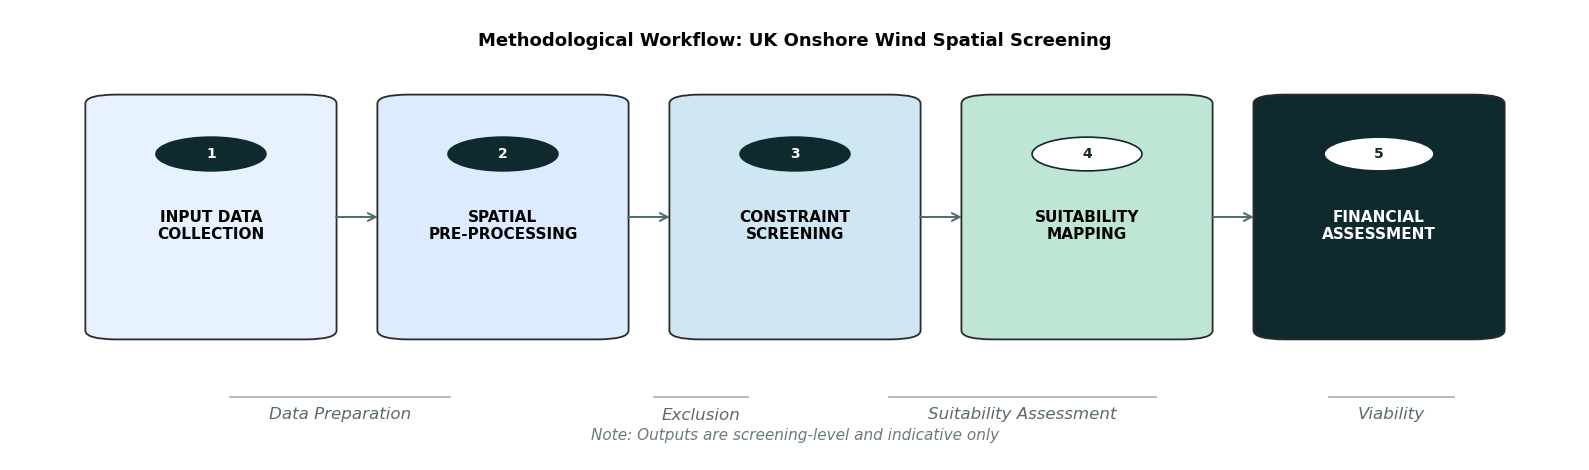

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Ellipse, FancyArrowPatch

steps = [
    "INPUT DATA\nCOLLECTION",
    "SPATIAL\nPRE-PROCESSING",
    "CONSTRAINT\nSCREENING",
    "SUITABILITY\nMAPPING",
    "FINANCIAL\nASSESSMENT",
]

box_colours = ["#E8F1FF", "#DCEBFF", "#CFE7F2", "#BFE6D5", "#0F2A2E"]

fig, ax = plt.subplots(figsize=(16, 4.8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

ax.text(
    0.5, 0.93,
    "Methodological Workflow: UK Onshore Wind Spatial Screening",
    ha="center", va="center", fontsize=13, fontweight="bold"
)

n = len(steps)
left, right = 0.06, 0.94
y, h = 0.28, 0.52
gap = 0.05
w = (right - left - (n - 1) * gap) / n

def text_colour(bg_hex):
    bg_hex = bg_hex.lstrip("#")
    r, g, b = [int(bg_hex[i:i+2], 16) / 255 for i in (0, 2, 4)]
    lum = 0.2126 * r + 0.7152 * g + 0.0722 * b
    return "black" if lum > 0.60 else "white"

for i, (label, col) in enumerate(zip(steps, box_colours), start=1):
    x = left + (i - 1) * (w + gap)

    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.012,rounding_size=0.02",
        linewidth=1.3, edgecolor="#2B2B2B", facecolor=col
    )
    ax.add_patch(box)

    cx, cy = x + w/2, y + h - 0.12
    oval_w, oval_h = 0.07, 0.075
    is_light_box = (i <= 3)
    oval_fill = "#0F2A2E" if is_light_box else "white"
    oval_edge = "#0F2A2E"

    ax.add_patch(Ellipse((cx, cy), oval_w, oval_h,
                         facecolor=oval_fill, edgecolor=oval_edge, linewidth=1.2))
    ax.text(
        cx, cy, str(i),
        ha="center", va="center",
        fontsize=10, fontweight="bold",
        color=("white" if oval_fill != "white" else "#0F2A2E")
    )

    ax.text(
        cx, y + h/2 - 0.02, label,
        ha="center", va="center",
        fontsize=11, fontweight="bold",
        color=text_colour(col), linespacing=1.15
    )

    if i < n:
        x_start = x + w + 0.01
        x_end = x + w + gap - 0.01
        ax.add_patch(FancyArrowPatch(
            (x_start, y + h/2), (x_end, y + h/2),
            arrowstyle="->", mutation_scale=14,
            linewidth=1.4, color="#4F6B6F"
        ))

# ----------------------------
# Guiding text below (BIGGER)
# ----------------------------
guide_fs = 12      # <- increase this further if needed
guide_note_fs = 11 # <- note line font size

lower_y_line = 0.14
lower_y_text = 0.10

ax.plot([0.14, 0.28], [lower_y_line, lower_y_line], color="#9FB3B6", lw=1.2)
ax.text(0.21, lower_y_text, "Data Preparation",
        ha="center", va="center", fontsize=guide_fs, style="italic", color="#5A6A6D")

ax.plot([0.41, 0.47], [lower_y_line, lower_y_line], color="#9FB3B6", lw=1.2)
ax.text(0.44, lower_y_text, "Exclusion",
        ha="center", va="center", fontsize=guide_fs, style="italic", color="#5A6A6D")

ax.plot([0.56, 0.73], [lower_y_line, lower_y_line], color="#9FB3B6", lw=1.2)
ax.text(0.645, lower_y_text, "Suitability Assessment",
        ha="center", va="center", fontsize=guide_fs, style="italic", color="#5A6A6D")

ax.plot([0.84, 0.92], [lower_y_line, lower_y_line], color="#9FB3B6", lw=1.2)
ax.text(0.88, lower_y_text, "Viability",
        ha="center", va="center", fontsize=guide_fs, style="italic", color="#5A6A6D")

ax.text(0.5, 0.055, "Note: Outputs are screening-level and indicative only",
        ha="center", va="center", fontsize=guide_note_fs, style="italic", color="#6B7A7D")

plt.tight_layout()
plt.show()

# fig.savefig("workflow_5steps_coloured.png", dpi=300, bbox_inches="tight")
